# Notebook for analyzing Krt17 Expression over HT and across genetic perturbations

###### Docker environment: https://hub.docker.com/repository/docker/eearlie/luad_sclc_ht/general

###### Laughney Lab
###### Ethan Earlie 

## Import Jobs

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as hc

import matplotlib.patches as patches
import matplotlib as mpl
import matplotlib
from matplotlib import rcParams
from adjustText import adjust_text

from scipy.stats import zscore
from copy import deepcopy
from kneed.knee_locator import KneeLocator
from sklearn.metrics.cluster import adjusted_rand_score
from skimage import filters
from scipy import stats

# Import helper functions from accompanying .py file:
from Krt17_helper_functions import *

import scipy
import sys
import os
import glob
import anndata
import itertools
import phenograph
import sklearn
import time

from os import path
from pathlib import Path
from scipy.ndimage import convolve
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
# Define output path and path to helper scripts:
output_dir_base = '/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/Revisions_0626/'
output_dir = output_dir_base
git_dir = './scripts/'
print(f'output_dir: {output_dir_base}')
print(f'git_dir: {git_dir}')

output_dir: /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/Revisions_0626/
git_dir: ./scripts/


In [3]:
# Set Jupyter formatting:
boolean_to_color = {True:'crimson',False:'steelblue'}

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:85% !important; }</style>"))
display(HTML("<style>.output_result { max-width:85% !important; }</style>"))

In [4]:
%matplotlib inline

sc.settings.figdir = output_dir_base
sc.set_figure_params(dpi=80, dpi_save=300)

matplotlib.style.use('default')
sns.set_style('white')

#cr.settings.verbosity = 2
plt.rcParams['figure.figsize']=(6,4) #rescale figures
sc.settings.verbosity = 4

## Import Data

In [5]:
# This h5ad file can be found for download through GEO here: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE248202
adata_HT = sc.read('/workdir/varmus_single_cell/data/NOBACKUP/Gardner_et-al-2023_processed_adata_histological_transformation_subset.h5ad')

In [6]:
adata_HT

AnnData object with n_obs × n_vars = 15828 × 24215
    obs: 'mt_frac', 'totReads', 'doublet_score', 'library_size', 'sample', 'origin', 'log_library_size', 'pheno_40', 'Basal cells_probs', 'Multiciliated cells_probs', 'Secretory cells_probs', 'Transitional Club-AT2_probs', 'PNEC_probs', 'Submucosal cells_probs', 'AT1_probs', 'AT2_probs', 'condition', 'ERPMT_pool_macrostate_probs', 'ERPMT_doxMRD_macrostate_probs', 'transformed_SCLC_macrostate_probs', 'AT2_1mo_macrostate_probs', 'top_macrostate', 'initial_states_probs', 'terminal_states_probs', 'project_batch', 'palantir_pseudotime', 'palantir_diff_score'
    var: 'gene_ids', 'n_cells_by_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'draw_graph', 'hvg', 'neighbors_40', 'origin_colors', 'pca', 'sample_colors', 'umap'
    obsm: 'DC', 'T_fwd_draw_graph_fa', 'X_draw_graph_fa', 'X_draw_graph_fa_extended', 'X_pca', 'X_umap', 'to_terminal_states'
    varm: 'PCs'
    layers: 'X', 'X_impute', 'logX'
    obsp: 'ne

In [7]:
adata_HT.obs['sample'].value_counts()

ERPMT_pool          5394
AT2_1mo             4429
ERPMT_3moMRD        3735
ERPMT_doxMRD        1949
transformed_SCLC     321
Name: sample, dtype: int64

In [9]:
# This h5ad file can be found for download through GEO here: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE248202
adata_TEC = sc.read('/workdir/varmus_single_cell/data/NOBACKUP/Gardner_et-al-2023_processed_adata_TEC_merged_new_samples.h5ad')

In [10]:
adata_TEC

AnnData object with n_obs × n_vars = 81395 × 23314
    obs: 'mt_frac', 'totReads', 'doublet_score', 'library_size', 'sample', 'origin', 'log_library_size', 'cellAssign_results', 'project_batch'
    var: 'gene_ids', 'n_cells_by_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Macro Cell Type_colors', 'Project_colors', 'cellAssign_results_colors', 'draw_graph', 'hvg', 'pca', 'sample_colors', 'umap'
    obsm: 'DC', 'X_OG_draw_graph_fa', 'X_draw_graph_fa', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X', 'X_impute', 'logX'

In [ ]:
# Define Krt17 expression status

adata_TEC.obs['Krt17_status'] = ['Krt17+' if x>0 else 'Krt17-' for x in np.ravel(adata_TEC[:,'Krt17'].layers['logX'])]

#stratify(adata_TEC, 'sample', 'Krt17_status', normalize=True)

## Analyze HT Dataset

### Krt17

In [13]:
adata_HT.obs['Krt17_status'] = ['Krt17+' if x>0 else 'Krt17-' for x in np.ravel(adata_HT[:,'Krt17'].layers['logX'])]

In [ ]:
cMap = {'Krt17-': '#ebebeb',
        'Krt17+': '#000000'}

cellType_frac_barplot(adata_HT, group_var='sample', 
                      group_order=['AT2_1mo', 'ERPMT_pool', 'ERPMT_doxMRD', 'ERPMT_3moMRD', 'transformed_SCLC'],
                      cellType_var='Krt17_status', cmap=cMap, prefix='HT_', figsize=(6,4))
cellType_frac_barplot(adata_HT, group_var='sample',
                      group_order=['AT2_1mo', 'ERPMT_pool', 'ERPMT_doxMRD', 'ERPMT_3moMRD', 'transformed_SCLC'],
                      cellType_var='Krt17_status', cmap=cMap, scaled=True, prefix='HT_', figsize=(6,4))

### Trends

### GSEA

In [ ]:
adata_HT

In [72]:
adata_sub = adata_HT[np.array(adata_HT.obs['sample'].map(lambda x: x in ['ERPMT_pool', 'ERPMT_doxMRD'])).astype(bool)].copy()

In [73]:
############### DEFINE MAST INPUT ###############

comp_list = ['Krt17_status']

input_file = '/workdir/varmus_single_cell/data/adata_HT_krt17_MRD_sub_status_comp.h5ad'

manual_var_list = ['Krt17+']

for variable in comp_list:
    
    if len(adata_sub.obs[variable].unique()) > 2:
        for var in adata_sub.obs[variable].unique():
            var = var.replace(' ','_').replace('/','_')
            adata_sub.obs[f'{var}_MAST_INPUT'] = [x.replace(' ','_').replace('/','_') 
                                              if x.replace(' ','_').replace('/','_')==var 
                                              else 'other' for x in adata_sub.obs[variable]]
    else:
        if 'other' in adata_sub.obs[variable].unique()[0]:
            var = adata_sub.obs[variable].unique()[1]
        else:
            var = manual_var_list[0]
            
        var = var.replace(' ','_').replace('/','_')
        adata_sub.obs[f'{var}_MAST_INPUT'] = [x.replace(' ','_').replace('/','_') 
                                                   if x.replace(' ','_').replace('/','_')==var 
                                                   else 'other' for x in adata_sub.obs[variable]]
        
adata_sub.write(input_file)

In [74]:
variable_sample_covar_map = {'Krt17_status': "TRUE"}

In [75]:
output_dir

'/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/'

In [76]:
adata_HT

AnnData object with n_obs × n_vars = 15828 × 24215
    obs: 'mt_frac', 'totReads', 'doublet_score', 'library_size', 'sample', 'origin', 'log_library_size', 'pheno_40', 'Basal cells_probs', 'Multiciliated cells_probs', 'Secretory cells_probs', 'Transitional Club-AT2_probs', 'PNEC_probs', 'Submucosal cells_probs', 'AT1_probs', 'AT2_probs', 'condition', 'ERPMT_pool_macrostate_probs', 'ERPMT_doxMRD_macrostate_probs', 'transformed_SCLC_macrostate_probs', 'AT2_1mo_macrostate_probs', 'top_macrostate', 'initial_states_probs', 'terminal_states_probs', 'project_batch', 'palantir_pseudotime', 'palantir_diff_score', 'Krt17_status', 'Krt5_status', 'Nearest_Archetype_n6'
    var: 'gene_ids', 'n_cells_by_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'draw_graph', 'hvg', 'neighbors_40', 'origin_colors', 'pca', 'sample_colors', 'umap', 'dendrogram_Nearest_Archetype'
    obsm: 'DC', 'T_fwd_draw_graph_fa', 'X_draw_graph_fa', 'X_draw_graph_fa_extended', 'X_pca', 'X_umap',


 Running MAST with ALL GENES and sample covar==TRUE for Krt17+ 
 
 ############################### 

/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/MAST_Results_LUAD_MRD_sub/Krt17_status/Krt17+//Krt17+_vs_other__all_others_ALL_GENEs.csv not found, setting force to True
calling bash -c 'R --vanilla --args --infile "/workdir/varmus_single_cell/data/adata_HT_krt17_MRD_sub_status_comp.h5ad" --data_field "logX" --outdir "/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/MAST_Results_LUAD_MRD_sub/Krt17_status/Krt17+/" --hvg_filter "FALSE"                  --sample_covariate "TRUE" --covar_field sample --cell_filter "FALSE" --groups Krt17+_MAST_INPUT --comp-groups "Krt17+" "other" --numcores 20 --outname-str "_all_others_ALL_GENEs" < /root/scripts/MAST_new.R' > /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/MAST_Results_LUAD_MRD_sub/Krt17_status/Krt17+//stdout_all_others_ALL_GENEs.txt 2>&1

Output from stdout file /workdir/varmus_single_cell/merged_p

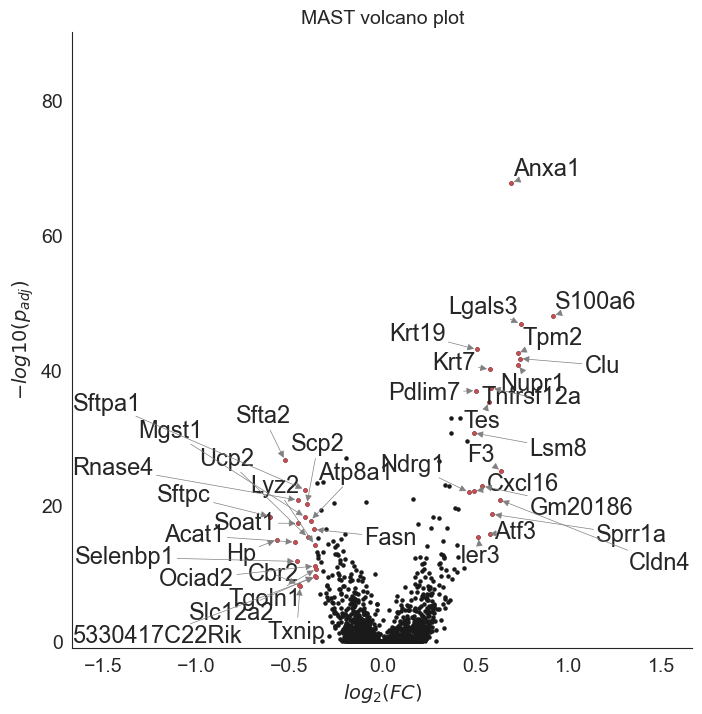

Running GSEA with ALL_GENEs and for Krt17_status 
 
 ############################### 

Dropping 71 results with no human gene mapping
calling bash -c 'parallel -j 20 < /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/GSEA_Results_ALL_GENEs_LUAD_MRD_sub/Krt17_status//commands.txt' > /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/GSEA_Results_ALL_GENEs_LUAD_MRD_sub/Krt17_status//GSEA_parallel_log.txt 2>&1

Output from stdout file /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/GSEA_Results_ALL_GENEs_LUAD_MRD_sub/Krt17_status//GSEA_parallel_log.txt is suppressed
Krt17+
(210, 11)
(210, 13)
Krt17+ 50


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


Krt17+ 34


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


Krt17+ 28


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


Krt17+ 16


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [ ]:
################### RUN MAST  ###################
    
for variable in comp_list:
    
    input_h5ad = input_file
    mast_outdir = output_dir + f'MAST_Results_LUAD_MRD_sub/{variable}/'
    !mkdir -p {mast_outdir}
    
    # Compare each var to rest otherwise use specified variable as positive case:
    if len(adata_sub.obs[variable].unique()) > 2:
        var_list = adata_sub.obs[variable].unique()
    
    # Only two conditions:
    else:
        var_list = manual_var_list
            
    for var in var_list:
        
        print('\n', f'Running MAST with ALL GENES and sample covar=={variable_sample_covar_map[variable]} for {var}', '\n', '\n',
          '###############################', '\n')
        
        ## Run only using HVGs:
        my_run_mast(var, 'other', 
                    hvg_filter='FALSE',
                    groupName=var+'_MAST_INPUT', 
                    sample_covariate=variable_sample_covar_map[variable],
                    infile=input_h5ad,
                    num_cores=20,
                    mast_outdir=mast_outdir+var+'/',
                    outname_str='_all_others_ALL_GENEs',
                    wait=True)

        
    ################### READ in MAST RESULTS ###################
    
    mast_results_df = pd.DataFrame()
    
    for x in os.listdir(mast_outdir):
        for y in os.listdir(mast_outdir+x):
            if y.endswith(".csv"):
                tmp_df = read_mast_results(mast_outdir+x+'/'+y)
                tmp_df['MAST_Info'] = y[:-4]
                mast_results_df = pd.concat([mast_results_df, tmp_df])
                
    #Filter out Rpl, Rps, and mt- genes
    mast_genes_filter = np.array((mast_results_df.index.map(lambda x: x[:3] not in 
                                                    ['Rpl', 'Rps', 'mt-']))).astype(bool)
    mast_results_df = mast_results_df[mast_genes_filter]
    #mast_results_df.head()
                
    ### Volcano Plots:    
    
    !mkdir -p {mast_outdir+'/Volcano_Plots/'}

    for x in mast_results_df['MAST_Info'].unique():
        
        label_list = mast_results_df[mast_results_df['MAST_Info'] == x].sort_values(by='log2FC', ascending=False)['log2FC'][:20].index.tolist() +\
                     mast_results_df[mast_results_df['MAST_Info'] == x].sort_values(by='log2FC', ascending=True)['log2FC'][:20].index.tolist()
        
        make_volcano_plot(mast_results_df[mast_results_df['MAST_Info'] == x], 
                          #mlog10_thresh=50, 
                          #log2FC_thresh = 0.5, 
                          #num_label=50,
                          label_list = label_list,
                          figsize=(8,8),
                          plot_outfile=mast_outdir+'/Volcano_Plots/' +x+ '.png')
        
        
    ##################### RUN GSEA #####################
    
    # Subset mast results df:
    mast_results_df_FULL = mast_results_df
    
    for gene_status in ['ALL_GENEs']:
        
        print(f'Running GSEA with {gene_status} and for {variable}', '\n', '\n',
               '###############################', '\n')
    
        # Only Care about results using all genes:
        mast_results_df = mast_results_df_FULL[mast_results_df_FULL.MAST_Info.map(lambda x: gene_status in x)]
        
        # define gsea pathways:
        gsea_dict = dict(zip(var_list,
                             ['lung_tumor_extended' for x in range(len([x.replace(' ','_').replace('/','_') 
                                                                        for x in var_list]))]))
        
        commands=[]
        outdir = output_dir + f'GSEA_Results_{gene_status}_LUAD_MRD_sub/{variable}/'
        !mkdir -p {outdir}
        
        for var in gsea_dict:
            
            var = var.replace(' ','_').replace('/','_')
            
            # the .gmt file is hosted here: https://github.com/LaughneyLab/Lung_Histological_Transformation/tree/main/data/
            ## point this to the GSEA files
            gmtfile = f'/workdir/varmus_single_cell/GSEA/{gsea_dict[var]}.gmt'
            if not path.exists(gmtfile):
                print(f'{gsea_file} not found')
                break
            ct0=var.replace(' ','_').replace('/','_')
            output_root=f'{outdir}/{ct0}'
            compName=f'{ct0}'
            if path.exists(f'{output_root}/{compName}.csv'):  # already run
                continue
                
            ## edit this with the statistic you want to test
            if var not in ['SCLC_vs_PNEC_MAST_INPUT', 'SCLC_vs_PNEC_cMYC_MAST_INPUT', 'PNEC_vs_PNEC_cMYC_MAST_INPUT']:
                scores = mast_results_df[mast_results_df.MAST_Info.map(lambda x: x.split('_vs_')[0] == var).astype(bool)][['scaled_rank_score']]
            else:
                scores = mast_results_df[mast_results_df.MAST_Info.map(lambda x: x.split('_HVG')[0]+'_MAST_INPUT' 
                                                                       == var).astype(bool)][['scaled_rank_score']]
            
            # score=0 often means no data/meaningless, remove these
            scores = scores.loc[scores.values != 0]
            scores = scores.loc[~np.isnan(scores.values)]
            if (scores.shape[0] < 2):
                continue
            scores.sort_values(by='scaled_rank_score', ascending=False, inplace=True)
            rank = gsea_linear_scale(scores)
            cmd = run_gsea(rank, output_root, gmtfile=gmtfile,
                           force=False, wait=True, label=compName, return_command_only=True,
                           gene_map=mToH_mapping)
            if cmd is None:
                print("ERROR ", compName)
            else:
                commands.append(cmd)
        gsea_command_file = f'{outdir}/commands.txt'
        with open(gsea_command_file, 'w') as filehandle:
            for command in commands:
                filehandle.write('%s\n' % command)
        run_in_background(f'parallel -j 20 < {gsea_command_file}', f'{outdir}/GSEA_parallel_log.txt', force=True, wait=True, quiet=True)
        
        
        ################ READ IN GSEA RESULTS ################
        gsea_results = pd.DataFrame()
        for var in gsea_dict.keys():
            
            var = var.replace(' ','_').replace('/','_')
            print(var)
            
            ## the .gmt file is hosted here: https://github.com/LaughneyLab/Lung_Histological_Transformation/tree/main/data/
            ## read in gmt file because we want to append category names with info in the second column
            gmtfile = f'/workdir/varmus_single_cell/GSEA/{gsea_dict[var]}.gmt'
            gmtMeta = pd.read_csv(gmtfile, index_col=None, usecols=[0,1], header=None, delimiter='\t')
            gmtMeta.columns = ['name','desc']
            
            ## gsea converts everything to upper case so we need to also
            gmtMeta['name'] = gmtMeta['name'].str.strip().str.upper()
            
            # we don't want to keep descriptions that start with '>', they are long and redundant
            gmtMeta.loc[gmtMeta['desc'].str.match('^>'),1]=''
            ct0=var.replace(' ','_').replace('/','_')
            
            ## this code is same as previous block
            compName=f'{ct0}'
            output_root=f'{outdir}/{ct0}'
            
            ## edit this with the statistic you want to test
            if var not in ['SCLC_vs_PNEC_MAST_INPUT', 'SCLC_vs_PNEC_cMYC_MAST_INPUT', 'PNEC_vs_PNEC_cMYC_MAST_INPUT']:
                scores = mast_results_df[mast_results_df.MAST_Info.map(lambda x: x.split('_vs_')[0] == var).astype(bool)][['scaled_rank_score']]
            else:
                scores = mast_results_df[mast_results_df.MAST_Info.map(lambda x: x.split('_HVG')[0]+'_MAST_INPUT' 
                                                                       == var).astype(bool)][['scaled_rank_score']]
            
            # score=0 often means no data/meaningless, remove these
            scores = scores.loc[scores.values != 0]
            scores = scores.loc[~np.isnan(scores.values)]
            
            if (scores.shape[0] < 2):
                continue
            # with readonly=True we do not run, just read in results
            currResults = run_gsea(None, output_root, force=False, wait=True, label=compName, readonly=True)
            currResults[variable] = var
            
            print(currResults.shape)
            currResults = currResults.merge(gmtMeta, on='name')
            print(currResults.shape)
            ## add description to the pathway name
            currResults['name'] = currResults['name']
            gsea_results = pd.concat([gsea_results, currResults])
        gsea_results['new_index'] = range(gsea_results.shape[0])
        gsea_results.set_index('new_index', drop=True, inplace=True)
        
        gsea_results['name'] = gsea_results['name'].map(lambda x: x.split('>')[0])
        
        ################ GO ENRICHMENT PLOTS ################
        
        gsea_results.nes = gsea_results.nes.replace('---', 0).astype(float)
        
        plt.ioff() # Prevent plots from automatically displaying in notebook
        
        fdrf_cutoff_list = [0.25, 0.1, 0.05, 0.01]
        
        outdir = output_dir + f'GSEA_Results_{gene_status}_LUAD_MRD_sub/'
        !mkdir -p {outdir+'/GO_Enrichment_Plots/'}
        
        for fdrf_cutoff in fdrf_cutoff_list:
        
            gsea_results_sub = gsea_results.copy()
                
            fdrf = gsea_results_sub['fdr_q'] < fdrf_cutoff
            
            for var in sorted(adata_HT.obs[variable].unique()):
                f = (gsea_results_sub[variable] == var) & (fdrf)
                
                if sum(f) == 0:
                    continue
                    
                print(var, sum(f))
                
                tmp = gsea_results_sub.loc[f]
                tmp.sort_values('nes', inplace=True, ascending=False)
                tmp = tmp.reset_index()
                
                fdrmin = np.min(np.array([x for x in gsea_results_sub.fdr_q if x!=0]))
                tmp.loc[tmp.fdr_q==0,'fdr_q'] = fdrmin
                tmp.fdr_q = tmp.fdr_q.apply(lambda x: -np.log10(x))
            
                sns.set_style('white')
                
                tmp['fdr_q_dir'] = [tmp.fdr_q.values[x]*np.sign(tmp.nes.values[x]) for x in range(len(tmp))]
                
                if len(tmp) > 50:
                    fig, ax = plt.subplots(figsize=(14,10))
                    #ax.tick_params(axis='both', which='both', labelsize=3)
                    plt.yticks(fontsize=4)
                else:
                    fig, ax = plt.subplots(figsize=(14,6))
                    #ax.tick_params(axis='both', which='both', labelsize=6)
                    plt.yticks(fontsize=6)
                
                plot = plt.scatter(x=tmp['name'], y=tmp['nes'], c=tmp['nes'], 
                                   cmap='RdBu_r', vmin=-4, vmax=4)
                plt.clf()
                
                cmap = plt.cm.RdBu_r
                norm = matplotlib.colors.Normalize(vmin=-2, vmax=2)
                
                colors = [matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap).to_rgba(x) 
                          for x in tmp.sort_values(by=['fdr_q_dir','nes'], ascending=False).nes]
                
                g = sns.barplot(data=tmp, 
                                x='fdr_q_dir',
                                y='name',
                                order=tmp.sort_values(by=['fdr_q_dir','nes'], ascending=False).name)
                
                for i,thisbar in enumerate(g.patches):
                    thisbar.set_alpha(1)
                    thisbar.set_edgecolor('black')
                    thisbar.set_linewidth(0.5)
                    thisbar.set_color(colors[i])
                
                plt.ylabel('')
                
                if len(tmp) > 50:
                    plt.yticks(fontsize=4)
                else:
                    plt.yticks(fontsize=6)
                
                plt.xlabel('-log10(FDR) * sign(NES)')
                
                plt.savefig(outdir+f'/GO_Enrichment_Plots/'+var+f'_Pathway_GO_Bar_Plot_Directed_FDR_{fdrf_cutoff}'+ '.png',
                            dpi=400,
                            bbox_inches='tight',
                            transparent=True)
                plt.close(fig)
            
        plt.ion()

In [ ]:
for gene_status in ['ALL_GENEs']:

    print(f'Running GSEA with {gene_status} and for {variable}', '\n', '\n',
           '###############################', '\n')

    # Only Care about results using all genes:
    mast_results_df = mast_results_df_FULL[mast_results_df_FULL.MAST_Info.map(lambda x: gene_status in x)]

    # define gsea pathways:
    gsea_dict = dict(zip(var_list,
                         ['lung_tumor_extended' for x in range(len([x.replace(' ','_').replace('/','_') 
                                                                    for x in var_list]))]))

    commands=[]
    outdir = output_dir + f'GSEA_Results_{gene_status}_LUAD_MRD_sub/{variable}/'
    !mkdir -p {outdir}

    for var in gsea_dict:

        var = var.replace(' ','_').replace('/','_')

        ## point this to the GSEA files
        # the .gmt file is hosted here: https://github.com/LaughneyLab/Lung_Histological_Transformation/tree/main/data/
        gmtfile = f'/workdir/varmus_single_cell/GSEA/{gsea_dict[var]}.gmt'
        if not path.exists(gmtfile):
            print(f'{gsea_file} not found')
            break
        ct0=var.replace(' ','_').replace('/','_')
        output_root=f'{outdir}/{ct0}'
        compName=f'{ct0}'
        if path.exists(f'{output_root}/{compName}.csv'):  # already run
            continue

        scores = mast_results_df[mast_results_df.MAST_Info.map(lambda x: x.split('_vs_')[0] == var).astype(bool)][['scaled_rank_score']]
        
        # in my case score=0 often means no data/meaningless, remove these
        scores = scores.loc[scores.values != 0]
        scores = scores.loc[~np.isnan(scores.values)]
        if (scores.shape[0] < 2):
            continue
        scores.sort_values(by='scaled_rank_score', ascending=False, inplace=True)
        rank = gsea_linear_scale(scores)
        cmd = run_gsea(rank, output_root, gmtfile=gmtfile,
                       force=False, wait=True, label=compName, return_command_only=True,
                       gene_map=mToH_mapping)
        if cmd is None:
            print("ERROR ", compName)
        else:
            commands.append(cmd)
    gsea_command_file = f'{outdir}/commands.txt'
    with open(gsea_command_file, 'w') as filehandle:
        for command in commands:
            filehandle.write('%s\n' % command)
    run_in_background(f'parallel -j 20 < {gsea_command_file}', f'{outdir}/GSEA_parallel_log.txt', force=True, wait=True, quiet=True)


    ################ READ IN GSEA RESULTS ################
    gsea_results = pd.DataFrame()
    for var in gsea_dict.keys():

        var = var.replace(' ','_').replace('/','_')

        print(var)

        # the .gmt file is hosted here: https://github.com/LaughneyLab/Lung_Histological_Transformation/tree/main/data/
        ## read in gmt file because we want to append category names with info in the second column
        gmtfile = f'/workdir/varmus_single_cell/GSEA/{gsea_dict[var]}.gmt'
        gmtMeta = pd.read_csv(gmtfile, index_col=None, usecols=[0,1], header=None, delimiter='\t')
        gmtMeta.columns = ['name','desc']

        ## gsea converts everything to upper case so we need to also
        gmtMeta['name'] = gmtMeta['name'].str.strip().str.upper()

        # we don't want to keep descriptions that start with '>', they are long and redundant
        gmtMeta.loc[gmtMeta['desc'].str.match('^>'),1]=''
        ct0=var.replace(' ','_').replace('/','_')

        ## this code is same as previous block
        compName=f'{ct0}'
        output_root=f'{outdir}/{ct0}'

        ## edit this with the statistic you want to test
        if var not in ['SCLC_vs_PNEC_MAST_INPUT', 'SCLC_vs_PNEC_cMYC_MAST_INPUT', 'PNEC_vs_PNEC_cMYC_MAST_INPUT']:
            scores = mast_results_df[mast_results_df.MAST_Info.map(lambda x: x.split('_vs_')[0] == var).astype(bool)][['scaled_rank_score']]
        else:
            scores = mast_results_df[mast_results_df.MAST_Info.map(lambda x: x.split('_HVG')[0]+'_MAST_INPUT' 
                                                                   == var).astype(bool)][['scaled_rank_score']]

        # in my case score=0 often means no data/meaningless, remove these
        scores = scores.loc[scores.values != 0]
        scores = scores.loc[~np.isnan(scores.values)]

        if (scores.shape[0] < 2):
            continue
        # with readonly=True we do not run, just read in results
        currResults = run_gsea(None, output_root, force=False, wait=True, label=compName, readonly=True)
        currResults[variable] = var

        print(currResults.shape)
        currResults = currResults.merge(gmtMeta, on='name')
        print(currResults.shape)
        ## add description to the pathway name
        currResults['name'] = currResults['name']
        gsea_results = pd.concat([gsea_results, currResults])
    gsea_results['new_index'] = range(gsea_results.shape[0])
    gsea_results.set_index('new_index', drop=True, inplace=True)

    gsea_results['name'] = gsea_results['name'].map(lambda x: x.split('>')[0])

    ################ GO ENRICHMENT PLOTS ################

    sns.set(font_scale=1.5)
    
    gsea_results.nes = gsea_results.nes.replace('---', 0).astype(float)

    plt.ioff() # Prevent plots from automatically displaying in notebook

    fdrf_cutoff_list = [0.25, 0.1, 0.05, 0.01]

    outdir = output_dir + f'GSEA_Results_{gene_status}_LUAD_MRD_sub/'
    !mkdir -p {outdir+'/GO_Enrichment_Plots/'}

    for fdrf_cutoff in fdrf_cutoff_list:

        gsea_results_sub = gsea_results.copy()

        fdrf = gsea_results_sub['fdr_q'] < fdrf_cutoff

        for var in sorted(adata_HT.obs[variable].unique()):
            f = (gsea_results_sub[variable] == var) & (fdrf)

            if sum(f) == 0:
                continue

            print(var, sum(f))

            tmp = gsea_results_sub.loc[f]
            tmp.sort_values('nes', inplace=True, ascending=False)
            tmp = tmp.reset_index()

            fdrmin = np.min(np.array([x for x in gsea_results_sub.fdr_q if x!=0]))
            tmp.loc[tmp.fdr_q==0,'fdr_q'] = fdrmin

            tmp.fdr_q = tmp.fdr_q.apply(lambda x: -np.log10(x))

            sns.set_style('white')

            tmp['fdr_q_dir'] = [tmp.fdr_q.values[x]*np.sign(tmp.nes.values[x]) for x in range(len(tmp))]

            tmp.name = tmp.name.map(lambda x: x.replace('_', ' '))
            
            if len(tmp) > 50:
                fig, ax = plt.subplots(figsize=(14,10))
                #ax.tick_params(axis='both', which='both', labelsize=3)
                plt.yticks(fontsize=4)
            else:
                fig, ax = plt.subplots(figsize=(10,9))
                #ax.tick_params(axis='both', which='both', labelsize=6)
                plt.yticks(fontsize=8)

            plot = plt.scatter(x=tmp['name'], y=tmp['nes'], c=tmp['nes'], 
                               cmap='RdBu_r', vmin=-4, vmax=4)
            plt.clf()
            plt.colorbar(plot)

            cmap = plt.cm.RdBu_r
            #norm = matplotlib.colors.Normalize(vmin=-max(abs(tmp.nes)), vmax=max(abs(tmp.nes)))
            norm = matplotlib.colors.Normalize(vmin=-4, vmax=4)

            colors = [matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap).to_rgba(x) 
                      for x in tmp.sort_values(by=['fdr_q_dir','nes'], ascending=False).nes]

            g = sns.barplot(data=tmp, 
                            x='fdr_q_dir',
                            y='name',
                            order=tmp.sort_values(by=['fdr_q_dir','nes'], ascending=False).name)

            for i,thisbar in enumerate(g.patches):
                thisbar.set_alpha(1)
                thisbar.set_edgecolor('black')
                thisbar.set_linewidth(0.5)
                thisbar.set_color(colors[i])

            plt.ylabel('')

            if len(tmp) > 50:
                plt.yticks(fontsize=4)
            else:
                plt.yticks(fontsize=8)

            plt.xlabel('-log10(FDR) * sign(NES)')

            plt.savefig(outdir+f'/GO_Enrichment_Plots/'+var+f'_Pathway_GO_Bar_Plot_Directed_FDR_{fdrf_cutoff}'+ '.svg',
                        dpi=400,
                        bbox_inches='tight',
                        transparent=True)
            plt.close(fig)

    plt.ion()

sns.set(font_scale=1)

Running GSEA with ALL_GENEs and for Krt17_status 
 
 ############################### 

calling bash -c 'parallel -j 20 < /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/GSEA_Results_ALL_GENEs_LUAD_MRD_sub/Krt17_status//commands.txt' > /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/GSEA_Results_ALL_GENEs_LUAD_MRD_sub/Krt17_status//GSEA_parallel_log.txt 2>&1

Output from stdout file /workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/GSEA_Results_ALL_GENEs_LUAD_MRD_sub/Krt17_status//GSEA_parallel_log.txt is suppressed
Krt17+
(210, 11)
(210, 13)
Krt17+ 50


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:172: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().


Krt17+ 34


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:172: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().


Krt17+ 28


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:172: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().


Krt17+ 16


/usr/local/lib/python3.7/dist-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:172: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().


## Analyze Full Tumor-Epithelium Dataset

### Krt17

In [14]:
adata_TEC.obs['Krt17_status'] = ['Krt17+' if x>0 else 'Krt17-' for x in np.ravel(adata_TEC[:,'Krt17'].layers['logX'])]

In [15]:
adata_TEC.obs['Krt17_status'].value_counts()

Krt17-    79463
Krt17+     1932
Name: Krt17_status, dtype: int64

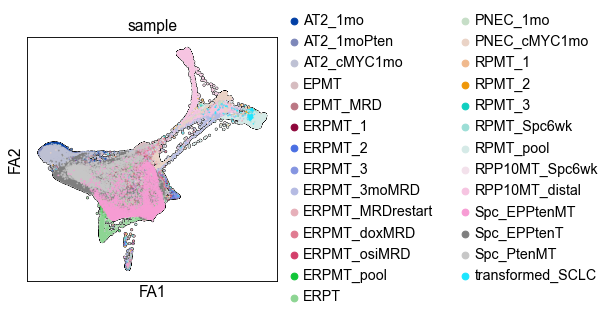

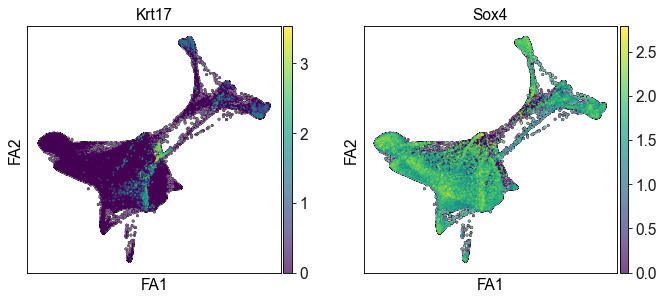

In [54]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300)

adata_TEC.X = adata_TEC.layers['logX']

sc.pl.draw_graph(adata_TEC, s=10, add_outline=True, color=f'sample')
sc.pl.draw_graph(adata_TEC, s=10, add_outline=True, cmap='viridis', color=[f'Krt17', 'Sox4'])

## All MRD subset

In [169]:
# Subset to all MRD samples:
adata_sub = adata_TEC[np.array(adata_TEC.obs['sample'].map(lambda x: x in 
                                                           ['ERPMT_3moMRD', 'ERPMT_doxMRD', 'ERPMT_osiMRD', 'ERPMT_MRDrestart'])).astype(bool)].copy()

In [170]:
adata_sub.obs['sample'].value_counts()

ERPMT_osiMRD        7019
ERPMT_MRDrestart    4804
ERPMT_3moMRD        3742
ERPMT_doxMRD        2001
Name: sample, dtype: int64

extracting highly variable genes
    finished (0:00:06)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
/usr/local/lib/python3.7/dist-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Found 4440 highly variable genes
/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225//hvgs_scanpy_cellranger_batch_key_sample.png


computing PCA
    on highly variable genes
    with n_comps=100
    finished (0:00:09)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PC1', 'PC2', ..., the loadings (adata.var)
    'pca_variance', the variance / eigenvalues (adata.uns)
    'pca_variance_ratio', the variance ratio (adata.uns)


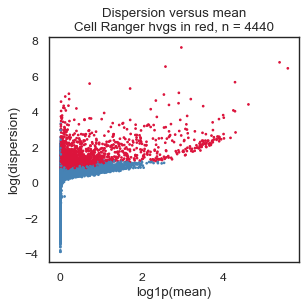

In [171]:
# Compute HVGs:
sns.set(style='white')
adata_sub.X = adata_sub.layers['X']

batch_key = 'sample'
sc.pp.highly_variable_genes(adata_sub, flavor='cell_ranger', batch_key=batch_key, n_bins=20, max_mean=np.inf)
colors_cell_ranger = [boolean_to_color[True] if x >0 else boolean_to_color[False]
                      for x in adata_sub.var['highly_variable']]
plt.scatter(np.log1p(adata_sub.var['means']), np.log(adata_sub.var['dispersions']),
            s=2, c=colors_cell_ranger)
plt.xlabel('log1p(mean)')
plt.ylabel('log(dispersion)')
n=sum(adata_sub.var["highly_variable"])
plt.title(f'Dispersion versus mean\nCell Ranger hvgs in red, n = {n}')
print(f'Found {n} highly variable genes')

fn = output_dir + f'/hvgs_scanpy_cellranger_batch_key_{batch_key}.png'
plt.tight_layout()
print(fn)
plt.savefig(fn, dpi=400)

# Compute PCA:
adata_sub.X =  adata_sub.layers['logX']
sc.pp.pca(adata_sub, n_comps=100)

/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225//PCA_linear_deviation_optimization.png
Linear Deviation Optimal PCs = 44


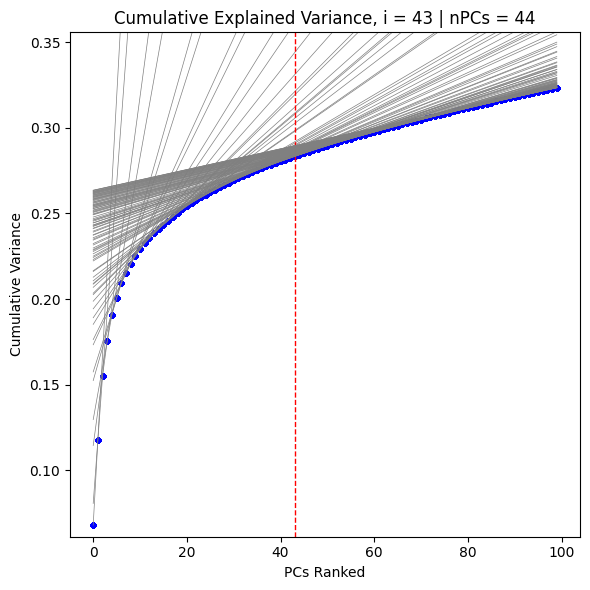

In [173]:
# Optimize for pRes

n = optimize_pcs(adata_sub, pca_name='pca', dev_thr=4e-6)
print(f'Linear Deviation Optimal PCs = {n}')

In [174]:
adata_sub.obsm[f'X_pca'] = adata_sub.obsm[f'X_pca'][:,:n]

In [175]:
adata_sub.obsm['X_pca'].shape

(17566, 44)

In [176]:
sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)

computing neighbors
    computing neighbors
    using 'X_pca' with n_pcs = 44
    computed neighbors (0:00:06)
    computed connectivities (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)


In [178]:
sample_cmap = {'AT2_1mo': '#AD0404', 
               'ERPMT_pool': '#ff0000', 
               'ERPMT_doxMRD': '#E896D1', 
               'ERPMT_3moMRD': '#9012F1', 
               'transformed_SCLC': '#46A8FF', 
               'RPMT_pool': '#0432ff',
               'ERPMT_MRDrestart': '#d2b14c',
               'ERPMT_doxMRD': '#eca9e5',
               'ERPMT_osiMRD': '#a2df8d'}

adata_sub.uns['sample_colors'] = [sample_cmap[x] for x in sorted(adata_sub.obs['sample'].unique())]

In [ ]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300)

sc.pl.umap(adata_sub, color='sample', add_outline=False, s=10, save='_MRDs_sample.svg')

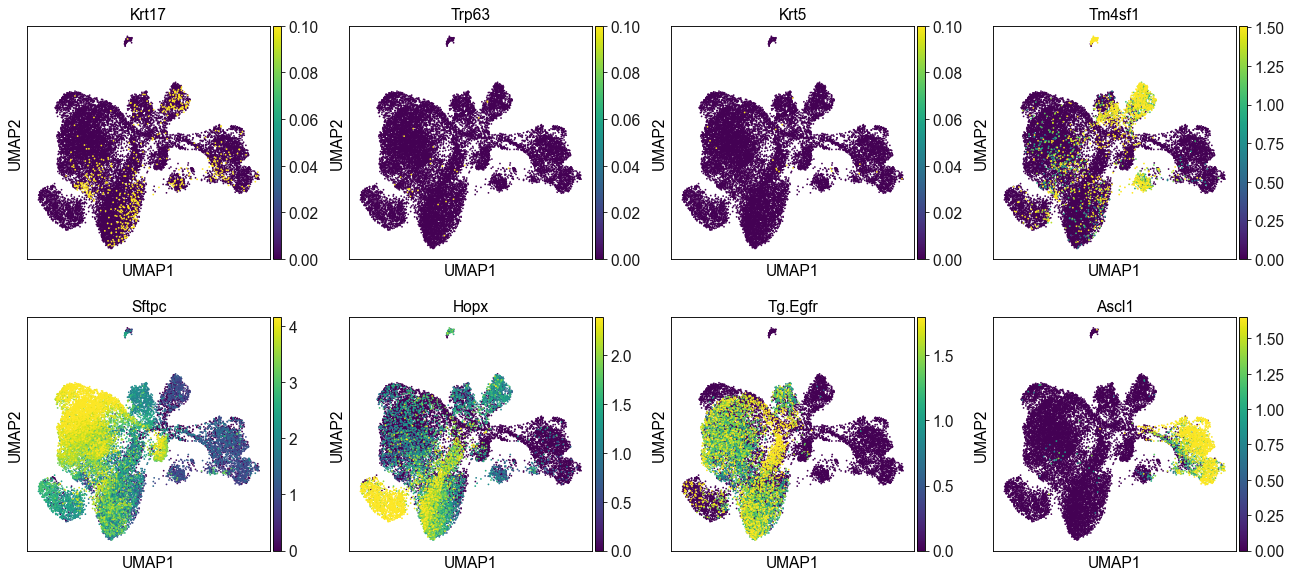

In [181]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300)

adata_sub.X = adata_sub.layers['logX']

genes = ['Krt17', 'Trp63', 'Krt5', 'Tm4sf1', 'Sftpc', 'Hopx', 'Tg.Egfr', 'Ascl1',]

#sc.pl.umap(adata_sub, color=genes, add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=10, save='_MRDs_select_genes.png')
sc.pl.umap(adata_sub, color=genes, add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=10, save='_MRDs_select_genes.svg')

In [182]:
mpas_genes = ['PHLDA1', 'SPRY2', 'SPRY4', 'DUSP4', 'DUSP6', 'CCND1', 'EPHA2', 'EPHA4', 'ETV4', 'ETV5']

# Map mouse genes to human:
mapped_genes = [("" if x.upper() in mToH_mapping.values() else x.upper()) 
                 if x not in mToH_mapping else mToH_mapping[x] for x in adata_sub.var.index]

# Check if each map mouse gene is in current signature:
current_mapped_genes = [x for x in range(len(mapped_genes)) 
                        if mapped_genes[x] in mpas_genes]

mapped_genes = adata_sub.var.index[current_mapped_genes].tolist()

gene_label_list = [x for x in mapped_genes + ['Sftpc', 'Tg.EGFR', 'Rest', 'Myc', 'Ascl1', 'Sox2', 'Sox9']
                   if x in adata_sub.var.index]

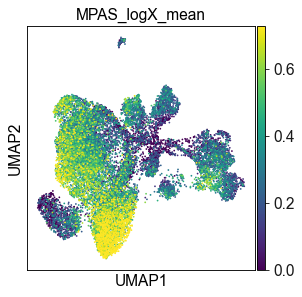

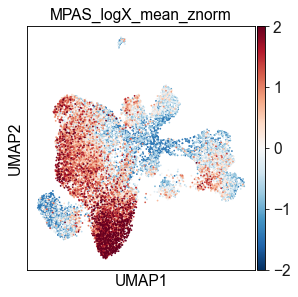

In [184]:
adata_sub.obs['MPAS_logX_mean'] = adata_sub[:,mapped_genes].layers['logX'].mean(axis=1)
adata_sub.obs['MPAS_logX_mean_znorm'] = scipy.stats.zscore(adata_sub.obs['MPAS_logX_mean'].values)
sc.pl.umap(adata_sub, color='MPAS_logX_mean', add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=10, save='_MRDs_MPAS_logX_mean.svg')
sc.pl.umap(adata_sub, color='MPAS_logX_mean_znorm', add_outline=False, vmin=-2, vmax=2, cmap='RdBu_r', ncols=4, s=10, save='_MRDs_MPAS_logX_mean_znorm.svg')

### Krt17+ MRD subset

In [185]:
# Subset to Krt17+ cells:
adata_sub.obs['Krt17_status'] = ['Krt17+' if x>0 else 'Krt17-' for x in np.ravel(adata_sub[:,'Krt17'].layers['logX'])]
adata_sub = adata_sub[adata_sub.obs['Krt17_status'] == 'Krt17+'].copy()

In [187]:
adata_sub.obs['sample'].value_counts()

ERPMT_doxMRD        181
ERPMT_MRDrestart    176
ERPMT_3moMRD        166
ERPMT_osiMRD         81
Name: sample, dtype: int64

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
/usr/local/lib/python3.7/dist-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Found 4936 highly variable genes
/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225//hvgs_scanpy_cellranger_batch_key_MRD_Krt17+_sample.png


computing PCA
    on highly variable genes
    with n_comps=100
    finished (0:00:00)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PC1', 'PC2', ..., the loadings (adata.var)
    'pca_variance', the variance / eigenvalues (adata.uns)
    'pca_variance_ratio', the variance ratio (adata.uns)


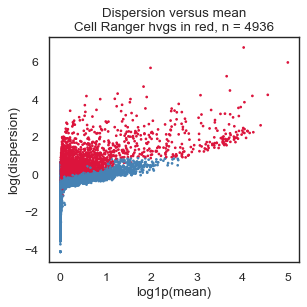

In [188]:
# Compute HVGs:
sns.set(style='white')
adata_sub.X = adata_sub.layers['X']

batch_key = 'sample'
sc.pp.highly_variable_genes(adata_sub, flavor='cell_ranger', batch_key=batch_key, n_bins=20, max_mean=np.inf)
colors_cell_ranger = [boolean_to_color[True] if x >0 else boolean_to_color[False]
                      for x in adata_sub.var['highly_variable']]
plt.scatter(np.log1p(adata_sub.var['means']), np.log(adata_sub.var['dispersions']),
            s=2, c=colors_cell_ranger)
plt.xlabel('log1p(mean)')
plt.ylabel('log(dispersion)')
n=sum(adata_sub.var["highly_variable"])
plt.title(f'Dispersion versus mean\nCell Ranger hvgs in red, n = {n}')
print(f'Found {n} highly variable genes')

fn = output_dir + f'/hvgs_scanpy_cellranger_batch_key_MRD_Krt17+_{batch_key}.png'
plt.tight_layout()
print(fn)
plt.savefig(fn, dpi=400)

# Compute PCA:
adata_sub.X =  adata_sub.layers['logX']
sc.pp.pca(adata_sub, n_comps=100)

/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225//PCA_linear_deviation_optimization.png
Linear Deviation Optimal PCs = 63


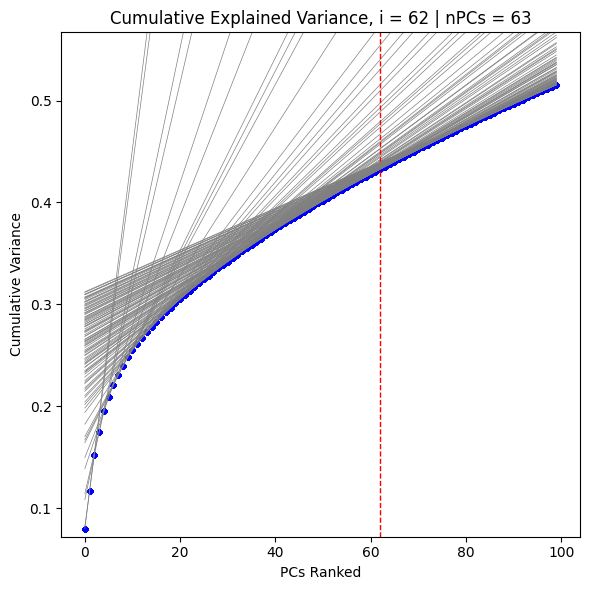

In [189]:
# Optimize for pRes

n = optimize_pcs(adata_sub, pca_name='pca', dev_thr=4e-6)
print(f'Linear Deviation Optimal PCs = {n}')

In [190]:
adata_sub.obsm[f'X_pca'] = adata_sub.obsm[f'X_pca'][:,:n]
sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)

In [194]:
sample_cmap = {'AT2_1mo': '#AD0404', 
               'ERPMT_pool': '#ff0000', 
               'ERPMT_doxMRD': '#E896D1', 
               'ERPMT_3moMRD': '#9012F1', 
               'transformed_SCLC': '#46A8FF', 
               'RPMT_pool': '#0432ff',
               'ERPMT_MRDrestart': '#d2b14c',
               'ERPMT_doxMRD': '#eca9e5',
               'ERPMT_osiMRD': '#a2df8d'}

adata_sub.uns['sample_colors'] = [sample_cmap[x] for x in sorted(adata_sub.obs['sample'].unique())]

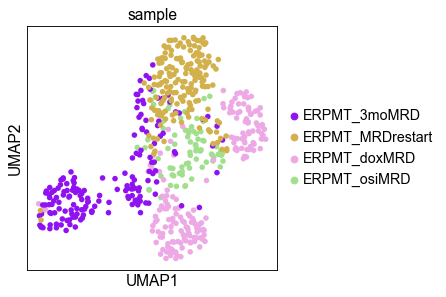

In [195]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300)

sc.pl.umap(adata_sub, color='sample', add_outline=False, s=100, save='_MRDs_Krt17_sub_sample.svg')

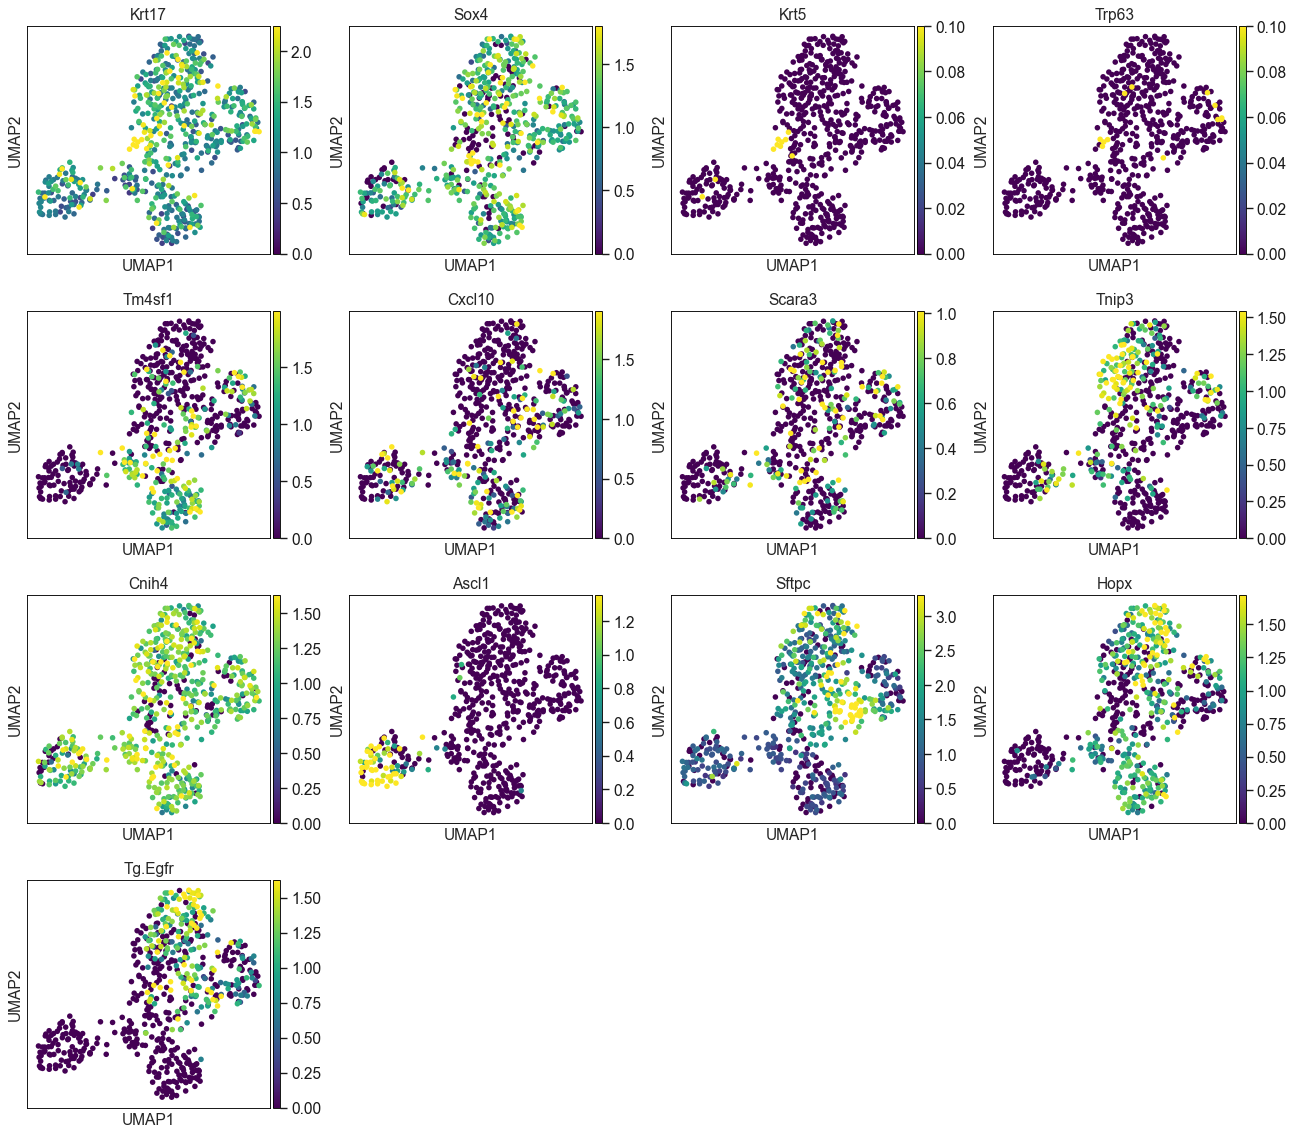

In [220]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300)

adata_sub.X = adata_sub.layers['logX']

#genes = ['Krt17', 'Cxcl10', 'Sftpc', 'Sox4', 'Scara3', 'Hopx', 'Krt5', 'Tnip3', 'Tg.Egfr', 'Tm4sf1', 'Cnih4', 'Ascl1']

genes = ['Krt17', 'Sox4', 'Krt5', 'Trp63',
         'Tm4sf1', 'Cxcl10', 'Scara3', 'Tnip3',
         'Cnih4', 'Ascl1', 'Sftpc', 'Hopx',
         'Tg.Egfr',]

#sc.pl.umap(adata_sub, color=genes, add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=10, save='_MRDs_select_genes.png')
sc.pl.umap(adata_sub, color=genes, add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=100, save='_MRDs_Krt17_sub_select_genes.svg')

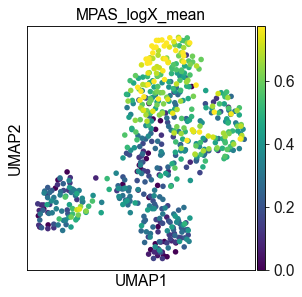

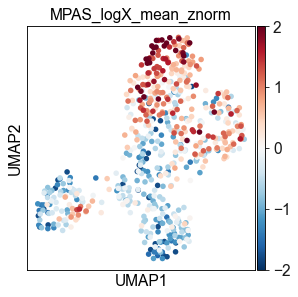

In [198]:
adata_sub.obs['MPAS_logX_mean'] = adata_sub[:,mapped_genes].layers['logX'].mean(axis=1)
adata_sub.obs['MPAS_logX_mean_znorm'] = scipy.stats.zscore(adata_sub.obs['MPAS_logX_mean'].values)
sc.pl.umap(adata_sub, color='MPAS_logX_mean', add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=100, save='_MRDs_MPAS_Krt17+_logX_mean.svg')
sc.pl.umap(adata_sub, color='MPAS_logX_mean_znorm', add_outline=False, vmin=-2, vmax=2, cmap='RdBu_r', ncols=4, s=100, save='_MRDs_MPAS_Krt17+_logX_mean_znorm.svg')

## Revisions update 06/26

In [13]:
# Include ERPMT pool sample as LUAD reference as requested in revisions:
adata_sub = adata_TEC[np.array(adata_TEC.obs['sample'].map(lambda x: x in 
                                                           ['ERPMT_pool', 'ERPMT_3moMRD', 'ERPMT_doxMRD', 'ERPMT_osiMRD', 'ERPMT_MRDrestart'])).astype(bool)].copy()

In [14]:
adata_sub.obs['sample'].value_counts()

ERPMT_osiMRD        7019
ERPMT_pool          5397
ERPMT_MRDrestart    4804
ERPMT_3moMRD        3742
ERPMT_doxMRD        2001
Name: sample, dtype: int64

In [15]:
adata_sub = adata_sub[adata_sub.obs['Krt17_status'] == 'Krt17+'].copy()

In [16]:
adata_sub.obs['sample'].value_counts()

ERPMT_doxMRD        181
ERPMT_MRDrestart    176
ERPMT_3moMRD        166
ERPMT_osiMRD         81
ERPMT_pool           44
Name: sample, dtype: int64

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
/usr/local/lib/python3.7/dist-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Found 4946 highly variable genes
/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/Revisions_0626//hvgs_scanpy_cellranger_batch_key_MRD_Krt17+_sample.png


computing PCA
    on highly variable genes
    with n_comps=100
    finished (0:00:00)
    and added
    'X_pca', the PCA coordinates (adata.obs)
    'PC1', 'PC2', ..., the loadings (adata.var)
    'pca_variance', the variance / eigenvalues (adata.uns)
    'pca_variance_ratio', the variance ratio (adata.uns)


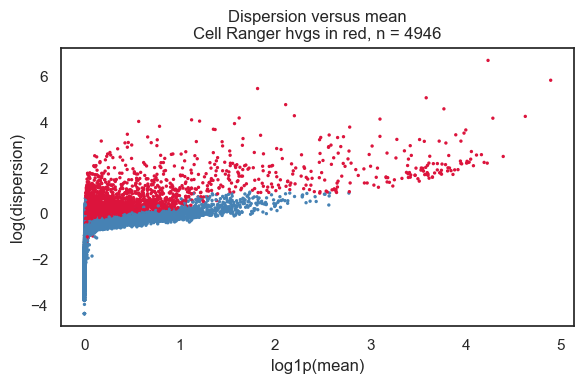

In [17]:
# Compute HVGs:
sns.set(style='white')
adata_sub.X = adata_sub.layers['X']

batch_key = 'sample'
sc.pp.highly_variable_genes(adata_sub, flavor='cell_ranger', batch_key=batch_key, n_bins=20, max_mean=np.inf)
colors_cell_ranger = [boolean_to_color[True] if x >0 else boolean_to_color[False]
                      for x in adata_sub.var['highly_variable']]
plt.scatter(np.log1p(adata_sub.var['means']), np.log(adata_sub.var['dispersions']),
            s=2, c=colors_cell_ranger)
plt.xlabel('log1p(mean)')
plt.ylabel('log(dispersion)')
n=sum(adata_sub.var["highly_variable"])
plt.title(f'Dispersion versus mean\nCell Ranger hvgs in red, n = {n}')
print(f'Found {n} highly variable genes')

fn = output_dir + f'/hvgs_scanpy_cellranger_batch_key_MRD_Krt17+_{batch_key}.png'
plt.tight_layout()
print(fn)
plt.savefig(fn, dpi=400)

# Compute PCA:
adata_sub.X =  adata_sub.layers['logX']
sc.pp.pca(adata_sub, n_comps=100)

/workdir/varmus_single_cell/merged_pipeline_out/RD_Krt17_0225/Revisions_0626//PCA_linear_deviation_optimization.png
Linear Deviation Optimal PCs = 28


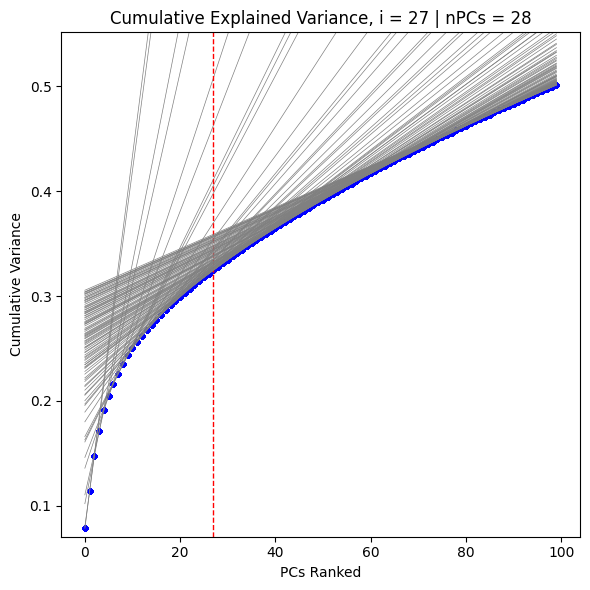

In [22]:
# Optimize for pRes

n = optimize_pcs(adata_sub, pca_name='pca', dev_thr=4e-6)
print(f'Linear Deviation Optimal PCs = {n}')

In [23]:
adata_sub.obsm[f'X_pca'] = adata_sub.obsm[f'X_pca'][:,:n]

In [24]:
adata_sub.obsm['X_pca'].shape

(648, 28)

In [ ]:
sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)

In [27]:
sample_cmap = {'AT2_1mo': '#AD0404', 
               'ERPMT_pool': '#ff0000', 
               'ERPMT_doxMRD': '#E896D1', 
               'ERPMT_3moMRD': '#9012F1', 
               'transformed_SCLC': '#46A8FF', 
               'RPMT_pool': '#0432ff',
               'ERPMT_MRDrestart': '#d2b14c',
               'ERPMT_doxMRD': '#eca9e5',
               'ERPMT_osiMRD': '#a2df8d'}

adata_sub.uns['sample_colors'] = [sample_cmap[x] for x in sorted(adata_sub.obs['sample'].unique())]

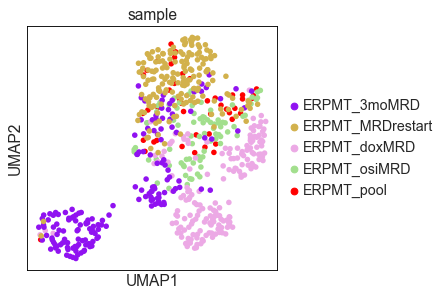

In [59]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300)

sc.pl.umap(adata_sub, color='sample', add_outline=False, s=100, save='_MRDs_Krt17_sub_sample.png')

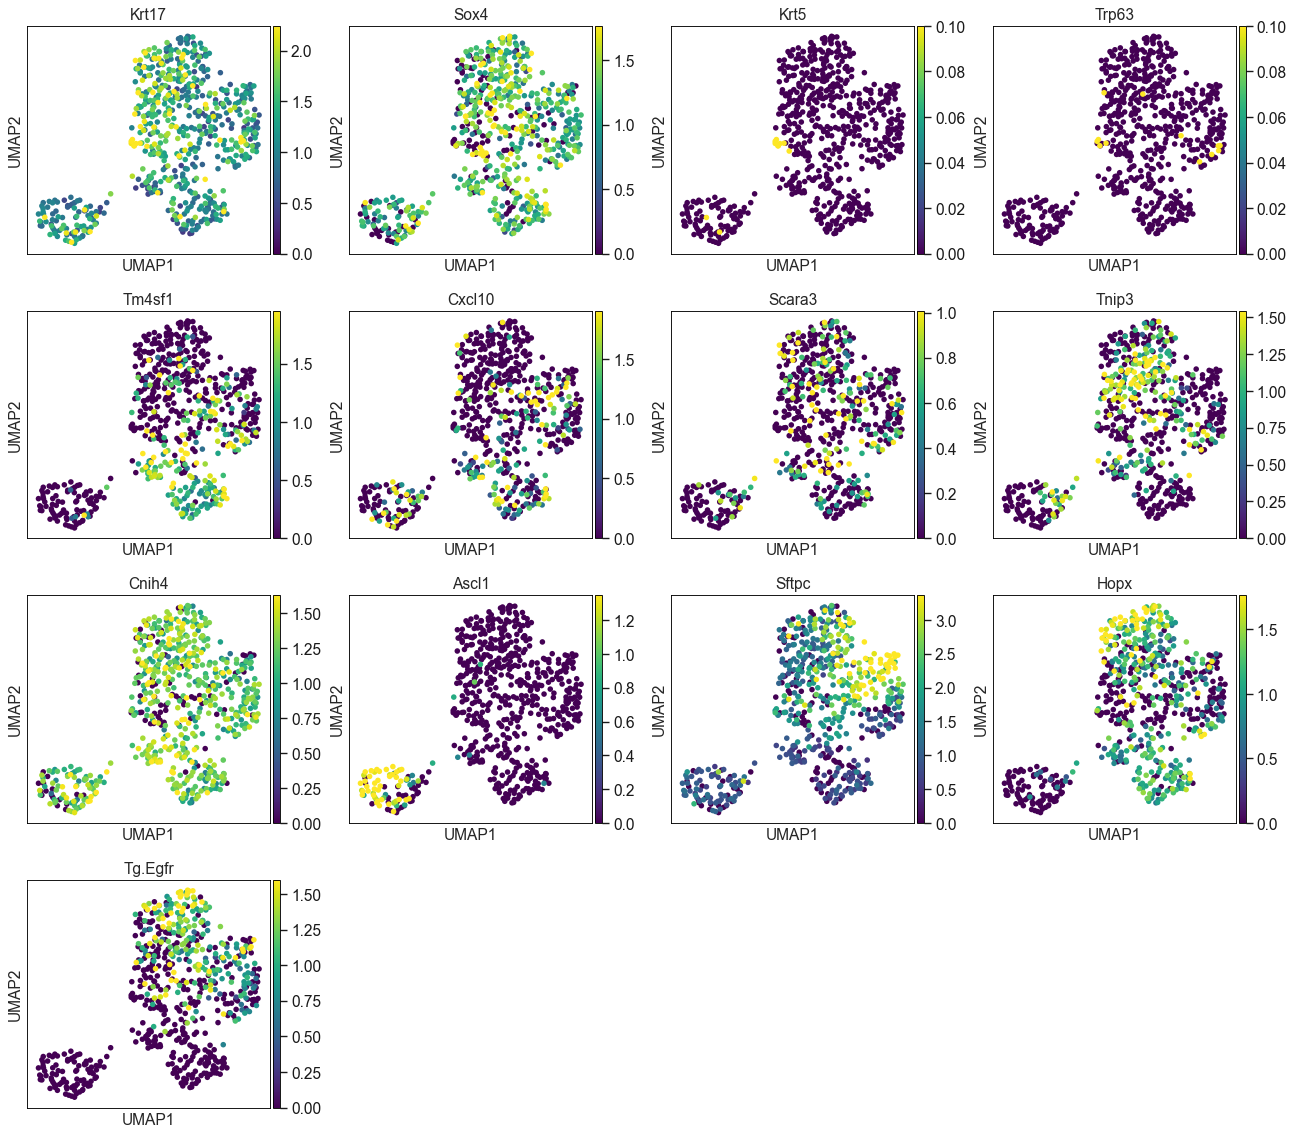

In [58]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300)

adata_sub.X = adata_sub.layers['logX']

#genes = ['Krt17', 'Cxcl10', 'Sftpc', 'Sox4', 'Scara3', 'Hopx', 'Krt5', 'Tnip3', 'Tg.Egfr', 'Tm4sf1', 'Cnih4', 'Ascl1']

genes = ['Krt17', 'Sox4', 'Krt5', 'Trp63',
         'Tm4sf1', 'Cxcl10', 'Scara3', 'Tnip3',
         'Cnih4', 'Ascl1', 'Sftpc', 'Hopx',
         'Tg.Egfr',]

#sc.pl.umap(adata_sub, color=genes, add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=10, save='_MRDs_select_genes.png')
sc.pl.umap(adata_sub, color=genes, add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=100, save='_MRDs_Krt17_sub_select_genes.png')

In [32]:
mpas_genes = ['PHLDA1', 'SPRY2', 'SPRY4', 'DUSP4', 'DUSP6', 'CCND1', 'EPHA2', 'EPHA4', 'ETV4', 'ETV5']

# Map mouse genes to human:
mapped_genes = [("" if x.upper() in mToH_mapping.values() else x.upper()) 
                 if x not in mToH_mapping else mToH_mapping[x] for x in adata_sub.var.index]

# Check if each map mouse gene is in current signature:
current_mapped_genes = [x for x in range(len(mapped_genes)) 
                        if mapped_genes[x] in mpas_genes]

mapped_genes = adata_sub.var.index[current_mapped_genes].tolist()

gene_label_list = [x for x in mapped_genes + ['Sftpc', 'Tg.EGFR', 'Rest', 'Myc', 'Ascl1', 'Sox2', 'Sox9']
                   if x in adata_sub.var.index]

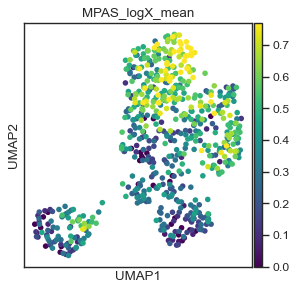

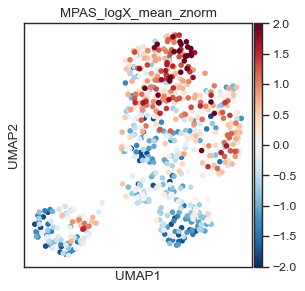

In [57]:
adata_sub.obs['MPAS_logX_mean'] = adata_sub[:,mapped_genes].layers['logX'].mean(axis=1)
adata_sub.obs['MPAS_logX_mean_znorm'] = scipy.stats.zscore(adata_sub.obs['MPAS_logX_mean'].values)
sc.pl.umap(adata_sub, color='MPAS_logX_mean', add_outline=False, vmin=0, vmax=get_vmax, cmap='viridis', ncols=4, s=100, save='_MRDs_MPAS_Krt17+_logX_mean.png')
sc.pl.umap(adata_sub, color='MPAS_logX_mean_znorm', add_outline=False, vmin=-2, vmax=2, cmap='RdBu_r', ncols=4, s=100, save='_MRDs_MPAS_Krt17+_logX_mean_znorm.png')

In [40]:
adata_sub.obs['sample'].value_counts()

ERPMT_doxMRD        181
ERPMT_MRDrestart    176
ERPMT_3moMRD        166
ERPMT_osiMRD         81
ERPMT_pool           44
Name: sample, dtype: int64

In [ ]:
sns.set(style='white', font_scale=1.5)
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()

df = pd.DataFrame(adata_sub.obs['sample'].value_counts()).reset_index().rename(columns={'index':'sample', 'sample': 'count'})

sns.barplot(data=df,
            x='sample', y='count', 
            order=['ERPMT_pool', 'ERPMT_osiMRD', 'ERPMT_3moMRD', 'ERPMT_MRDrestart', 'ERPMT_doxMRD'],
            hue='sample',
            palette=sample_cmap,
            edgecolor='black', linewidth=2, dodge=False,
#            **{'width':0.55}
            #order=adata.obs[['Macro Cell Type', 'Kim_prolif_mean']].groupby('Macro Cell Type').mean().sort_values(by='Kim_prolif_mean').index
           )

for patch in ax.patches:
    current_width = patch.get_width()
    diff = current_width - 0.55

    # Change the bar width
    patch.set_width(0.55)

    # Recenter the bar dynamically
    patch.set_x(patch.get_x() + diff * 0.5)
    
ax.get_legend().remove()

plt.xticks(rotation=90)
plt.title('Cell Count')
plt.savefig(f'{output_dir}/Krt17+_subset_sample_distribution_barplot.png', transparent=True, bbox_inches='tight', dpi=600)
sns.set(style='white', font_scale=1)

## HT Projections and Gene Trends

In [85]:
# This h5ad file can be found for download through GEO here: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE248202

adata_FULL = sc.read('/workdir/varmus_single_cell/data/NOBACKUP/Gardner_et-al-2023_processed_adata_histological_transformation_subset.h5ad')
adata_HVG = adata_FULL[:,adata_FULL.var['highly_variable'] == True].copy()

### FDL Projections

In [41]:
adata_HVG.obs['sample'].unique()

['ERPMT_pool', 'ERPMT_doxMRD', 'ERPMT_3moMRD', 'transformed_SCLC', 'AT2_1mo']
Categories (5, object): ['AT2_1mo', 'ERPMT_3moMRD', 'ERPMT_doxMRD', 'ERPMT_pool', 'transformed_SCLC']

In [42]:
sample_cmap = {'AT2_1mo': '#AD0404', 
               'ERPMT_pool': '#ff0000', 
               'ERPMT_doxMRD': '#E896D1', 
               'ERPMT_3moMRD': '#9012F1', 
               'transformed_SCLC': '#46A8FF', def st
               'RPMT_pool': '#0432ff',
               'ERPMT_MRDrestart': '#d2b14c'}

adata_FULL.uns['sample_colors'] = [sample_cmap[x] for x in sorted(adata_FULL.obs['sample'].unique())]
adata_HVG.uns['sample_colors'] = [sample_cmap[x] for x in sorted(adata_HVG.obs['sample'].unique())]

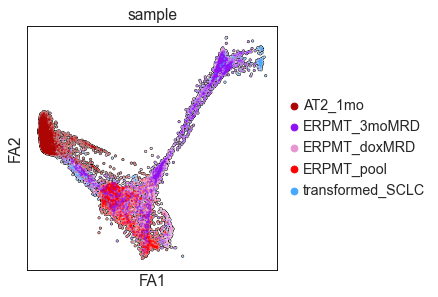

In [46]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300) 

sc.pl.draw_graph(adata_HVG, 
                 color='sample', 
                 s=10,
                 alpha=0.5,
                 add_outline=True,
                 save='_sample_FDR.svg')

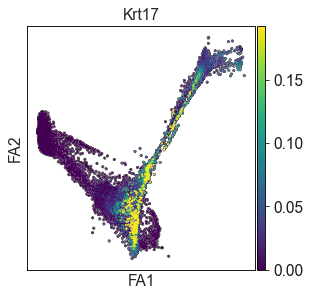

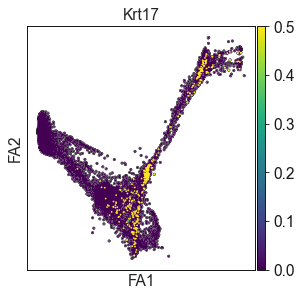

In [47]:
sc.settings.verbosity = 4
sc.set_figure_params(dpi=80, dpi_save=300) 

adata_FULL.X = adata_FULL.layers['X_impute']

sc.pl.draw_graph(adata_FULL, 
                 color='Krt17', 
                 s=10,
                 alpha=1,
                 cmap='viridis',
                 add_outline=True,
                 vmin='p02', vmax='p98',
                 save='_Krt17_imputed_FDL.svg')

adata_FULL.X = adata_FULL.layers['logX']

sc.pl.draw_graph(adata_FULL, 
                 color='Krt17', 
                 s=10,
                 alpha=1,
                 cmap='viridis',
                 add_outline=True,
                 vmin=0, vmax=0.5,
                 save='_Krt17_logX_FDL.svg')

### Interpret CellRank Results

In [50]:
subclusters = 'sample'

#### Gene Trends

In [87]:
adata_HVG.obsm['to_terminal_states_original'] = adata_HVG.obsm['to_terminal_states']
adata_HVG.obsm['to_terminal_states'] = cr.tl.Lineage(np.array(adata_HVG.obsm['to_terminal_states']),
                                                               names=['transformed_SCLC'],
                                                               colors=[sample_cmap['transformed_SCLC']])

In [ ]:
adata_HVG.obsm['to_terminal_states']

In [89]:
adata_FULL.obsm['to_terminal_states'] = adata_HVG.obsm['to_terminal_states']

##### Map Results to Full Gene adata

In [90]:
for col in adata_HVG.uns['macrostate_names']:
    
    adata_FULL.obs[f'{col}_macrostate_probs'] = adata_HVG[adata_FULL.obs.index].obs[f'{col}_macrostate_probs']

In [91]:
adata_FULL.obs[f'initial_states_probs'] = adata_HVG[adata_FULL.obs.index].obs[f'initial_states_probs']
adata_FULL.obs[f'terminal_states_probs'] = adata_HVG[adata_FULL.obs.index].obs[f'terminal_states_probs']

adata_FULL.obs[f'palantir_pseudotime_1'] = adata_HVG[adata_FULL.obs.index].obs[f'palantir_pseudotime_1']
adata_FULL.obs[f'palantir_diff_score_1'] = adata_HVG[adata_FULL.obs.index].obs[f'palantir_diff_score_1']

In [92]:
for x in ['DC', 'T_fwd_draw_graph_fa',
          'from_initial_states', 'initial_states_memberships', 
          'schur_vectors_bwd', 'schur_vectors_fwd', 'terminal_states_memberships', 
          'to_terminal_states']:
    
    adata_FULL.obsm[x] = adata_HVG[adata_FULL.obs.index].obsm[x]

##### Visualize

###### X Impute

In [101]:
mat = pd.DataFrame(adata_FULL.layers['X_impute'].copy())

for x in mat:
    v = mat[x]
    mat[x]  = (v - v.min()) / (v.max() - v.min())

adata_FULL.layers['X_impute_scaled'] = mat.values

adata_FULL.X = adata_FULL.layers['X_impute_scaled']

In [103]:
adata_FULL.X = adata_FULL.layers['X_impute']

model_FULL_unscaled = cr.ul.models.GAM(adata_FULL)

Computing trends using `1` core(s)


Missing Genes:  []


  0%|          | 0/4 [00:00<?, ?gene/s]

    Finish (0:00:01)
Plotting trends


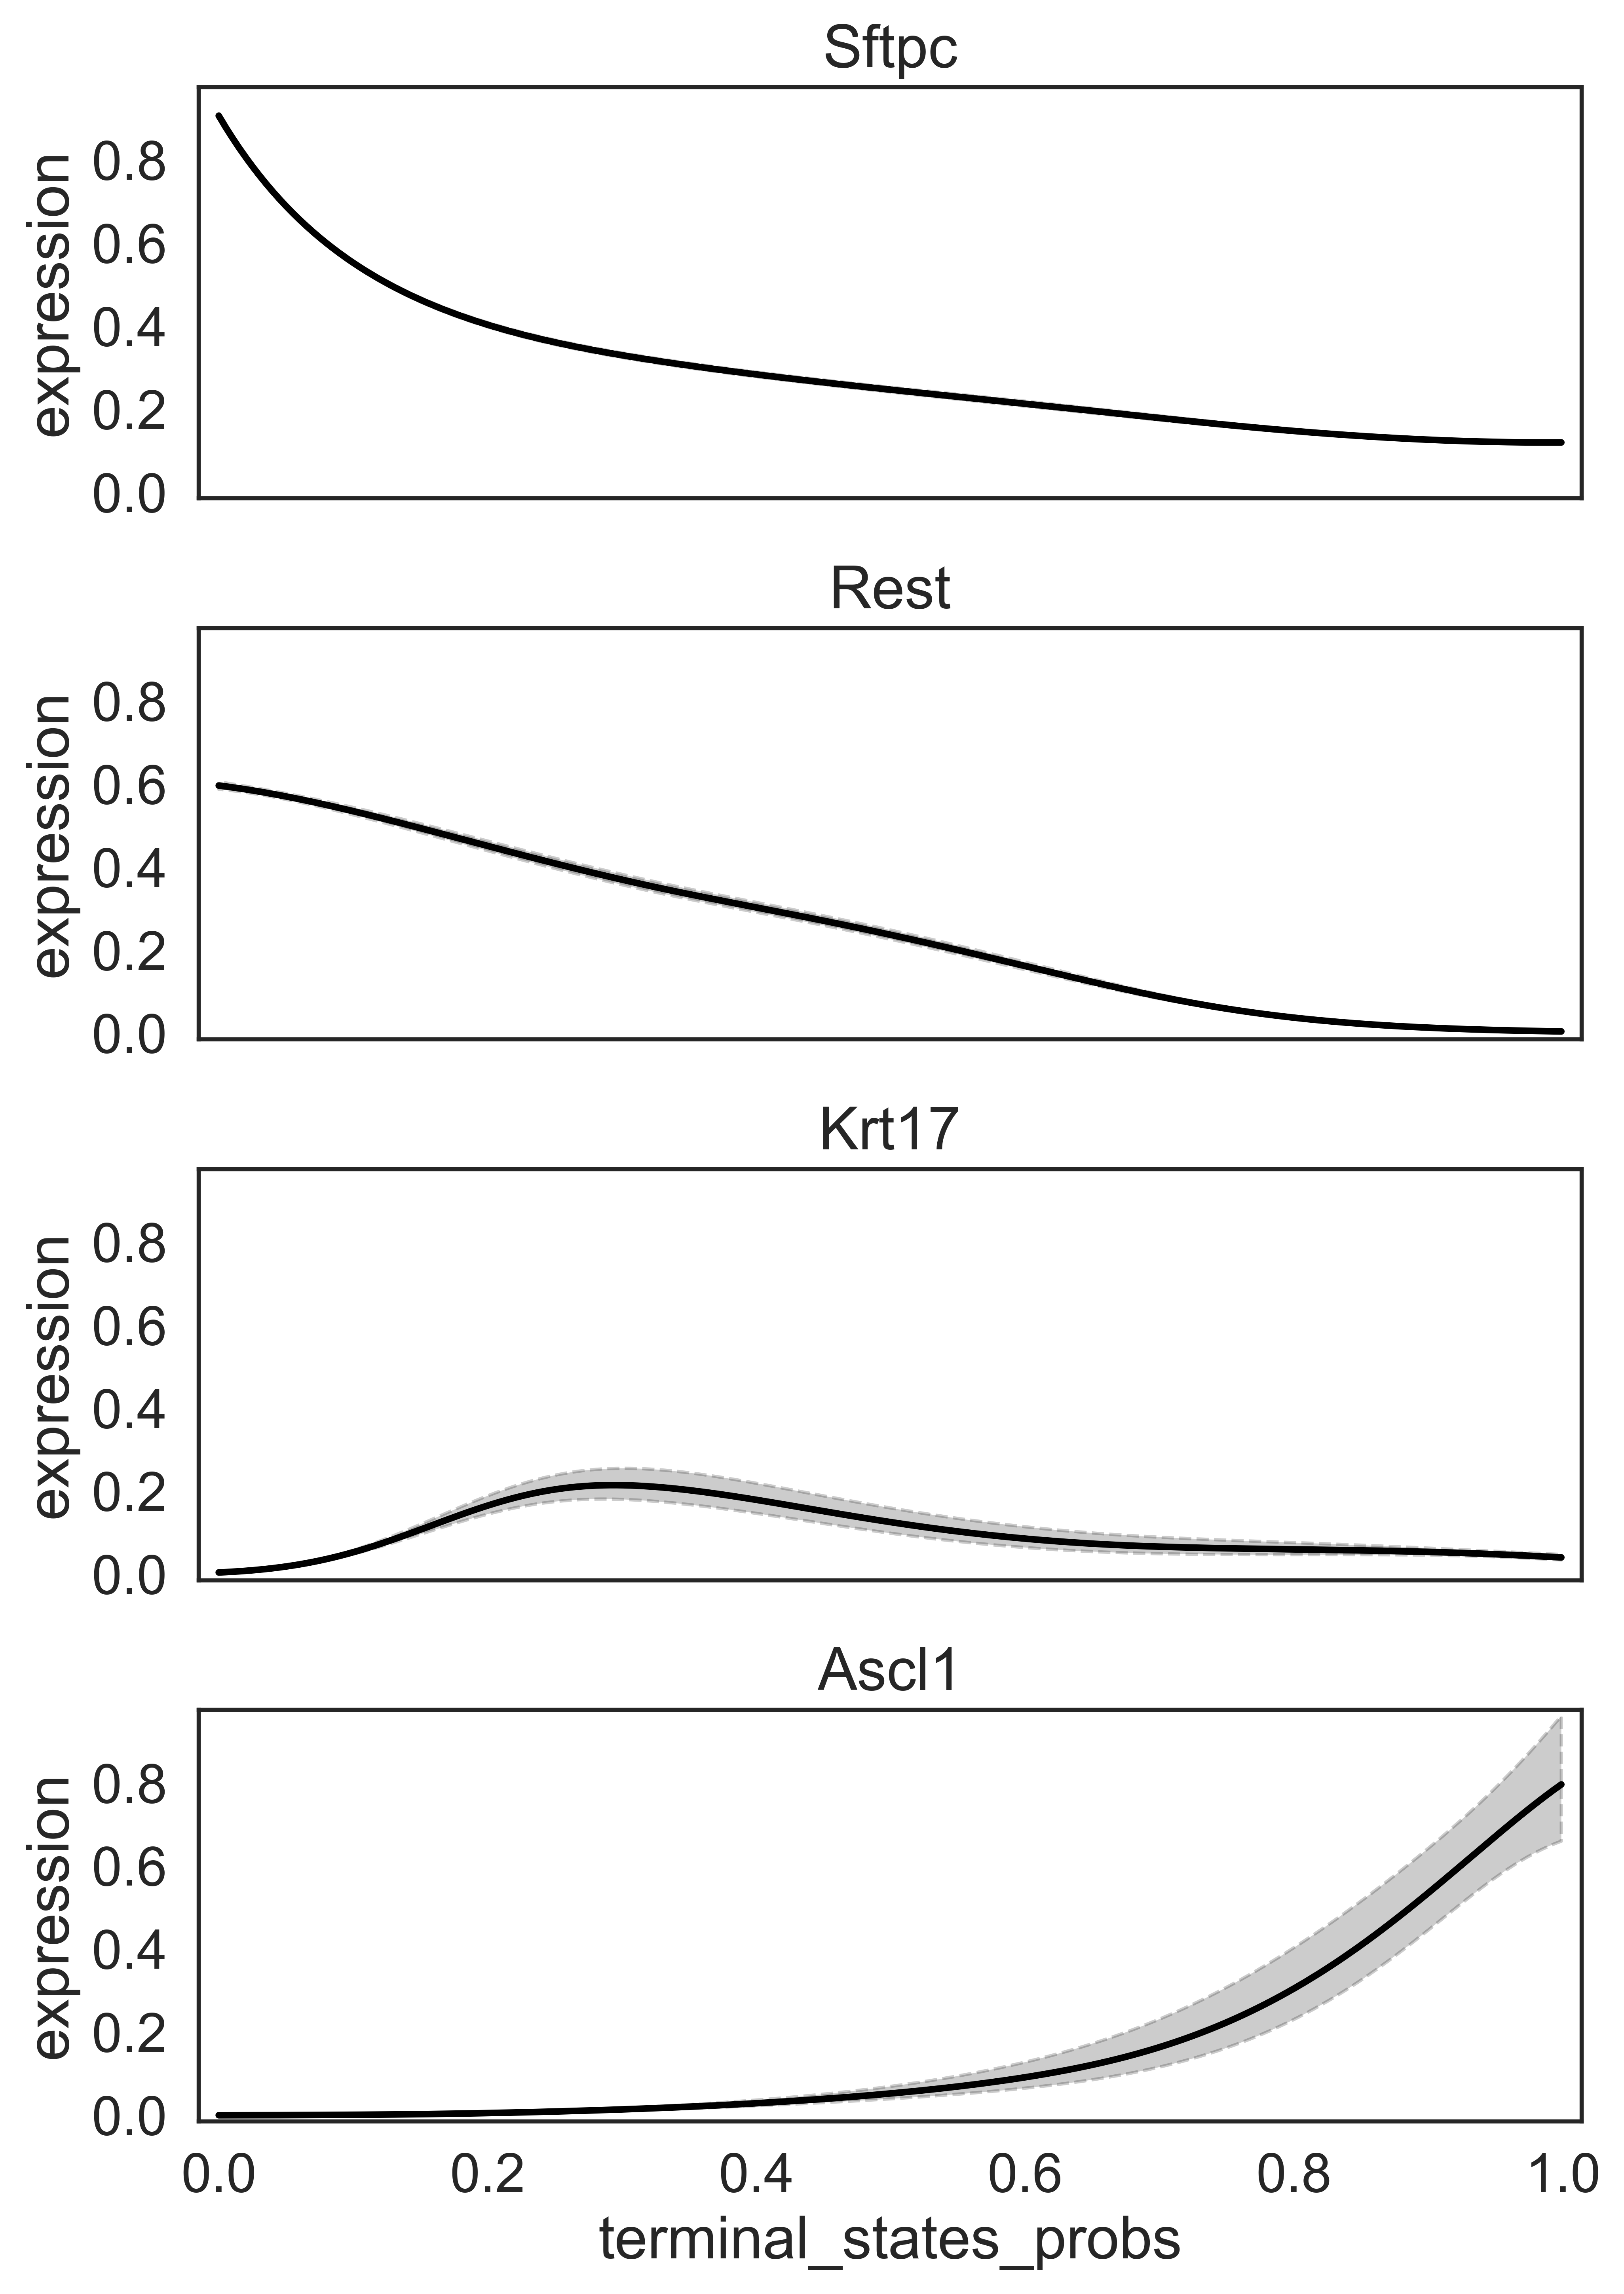

In [109]:
adata_FULL.X = adata_FULL.layers['X_impute_scaled']

sns.set(style='white', font_scale=1.5)

genes = ['Sftpc',
         'Rest',
         'Krt17',
         'Ascl1']

print('Missing Genes: ', [x for x in genes if x not in adata_FULL.var.index])

cr.pl.gene_trends(adata_FULL,
                  model=model_FULL_unscaled,
                  data_key="X",
                  genes=[x for x in genes if x in adata_FULL.var.index],
                  ncols=1,
                  time_key="terminal_states_probs",
                  lineages='transformed_SCLC',
                  same_plot=True,
                  hide_cells=True,
                  figsize=(7, 10),
                  n_test_points=200,
                  sharey=True,
                  legend_loc=None,
                  lineage_cmap=['#000000'],
                  dpi=600,
                  save=f'Select_Genes_Terminal_States_Probs_X_impute_scaled_matched_axis_Krt17_fig.svg')

sns.set(style='white', font_scale=1)